In [1]:
import sys
sys.path.insert(0, "../")

import numpy as np
from caliblab.models import MLPClassifier
from caliblab.datasets import Synthetic2DClassifier

/home/nkotelevskii/github/iclr_conformal_probability_calibration/conformal_probability_calibration/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# rng = np.random.default_rng(7)

# for K in [2, 10, 100, 1000]:
#     ds = Synthetic2DClassifier(
#         n_classes=K,
#         layout="grid" if K >= 10 else "circle",
#         spacing=1.0,
#         sigma_scale=0.35,
#         rng=rng,
#     )
#     # sample a modest batch
#     x, y, p = ds.sample(n=200)

#     # Bayes-optimal predictions under the true model:
#     y_hat = ds.predict(x)
#     pred_prob = ds.proba(x)
#     acc = (y_hat == y).mean()

#     # Peek at a few probabilities for the first sample
#     topk = min(5, K)
#     top_idx = np.argsort(-p[0])[:topk]
#     top_probs = p[0, top_idx]

#     print(f"\n=== K = {K} classes ===")
#     print(f"x shape: {x.shape}, y shape: {y.shape}, p shape: {p.shape}")
#     print(f"Bayes-optimal accuracy on sampled batch: {acc:.3f}")
#     print(f"First sample top-{topk} classes & probs:")
#     print(pred_prob.shape)
#     print(np.allclose(pred_prob.sum(-1), 1.))
#     print(list(zip(top_idx.tolist(), np.round(top_probs, 4).tolist())))

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [4]:
class Synth2DDataset(Dataset):
    """
    Pre-samples a fixed split so you can use standard DataLoaders.
    """
    def __init__(self, ds: Synthetic2DClassifier, n_samples: int, seed: int = 0):
        rng = np.random.default_rng(seed)
        # clone a dataset instance with a controlled RNG for reproducibility
        self.ds = ds
        self.x, self.y, _ = ds.sample(n_samples)
        self.x = self.x.astype(np.float32)
        self.y = self.y.astype(np.int64)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return torch.from_numpy(self.x[idx]), torch.tensor(self.y[idx])

In [5]:
# pytorch_synth2d_training.py
# ------------------------------------------------------------
# A self-contained training & evaluation script for the 2D synthetic dataset.
# - Dataset: Gaussian-mixture ground truth with up to 10k classes
# - Model: MLP(+Fourier features) -> Linear(K)
# - Loss: Cross-entropy + label smoothing
# - Eval: accuracy@1 / accuracy@5 / NLL / ECE
# ------------------------------------------------------------
import math
import numpy as np
from typing import Optional, Tuple, Literal

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ========= Synthetic dataset (same semantics as before) =========
class Synthetic2DClassifier:
    """
    2D synthetic classification with up to ~10k classes.
    Ground truth p(y|x) is an equal-prior, shared-covariance Gaussian mixture:
      p(y=k|x) ∝ N(x; μ_k, σ^2 I)
    """
    def __init__(
        self,
        n_classes: int,
        layout: Literal["grid", "circle"] = "grid",
        spacing: float = 1.0,
        sigma_scale: float = 0.35,
        center_jitter: float = 0.0,
        rng: Optional[np.random.Generator] = None,
        max_classes_per_chunk: int = 5000,
    ):
        assert n_classes >= 1
        self.K = n_classes
        self.layout = layout
        self.spacing = float(spacing)
        self.sigma_scale = float(sigma_scale)
        self.center_jitter = float(center_jitter)
        self.rng = rng if rng is not None else np.random.default_rng()
        self.max_classes_per_chunk = int(max_classes_per_chunk)

        self.mu = self._make_centers()
        if self.center_jitter > 0:
            self.mu += self.rng.normal(0.0, self.center_jitter, size=self.mu.shape)

        self.sigma = self.sigma_scale * self.spacing
        self.sigma2 = self.sigma ** 2

    def _make_centers(self) -> np.ndarray:
        if self.layout == "grid":
            g = int(np.ceil(np.sqrt(self.K)))
            xs = (np.arange(g) - (g - 1) / 2.0) * self.spacing
            xv, yv = np.meshgrid(xs, xs)
            grid = np.stack([xv.ravel(), yv.ravel()], axis=1)[: self.K]
            return grid.astype(np.float32)
        elif self.layout == "circle":
            radius = max(1e-6, self.spacing * self.K / (2 * np.pi))
            angles = np.linspace(0, 2 * np.pi, self.K, endpoint=False)
            cx = radius * np.cos(angles)
            cy = radius * np.sin(angles)
            return np.stack([cx, cy], axis=1).astype(np.float32)
        else:
            raise ValueError("layout must be 'grid' or 'circle'")

    def sample(self, n: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        y = self.rng.integers(0, self.K, size=n, dtype=np.int64)
        x = self.mu[y] + self.rng.normal(0.0, self.sigma, size=(n, 2)).astype(np.float32)
        p = self.proba(x)
        return x, y, p

    def proba(self, x: np.ndarray, chunk: Optional[int] = None) -> np.ndarray:
        x = np.asarray(x, dtype=np.float32)
        assert x.ndim == 2 and x.shape[1] == 2
        n, K = x.shape[0], self.K
        sigma2 = self.sigma2

        p = np.empty((n, K), dtype=np.float64)
        chunk = self.max_classes_per_chunk if chunk is None else int(chunk)

        max_logits = None
        x64 = x.astype(np.float64)
        x2 = np.sum(x64 ** 2, axis=1, keepdims=True)
        for start in range(0, K, chunk):
            end = min(K, start + chunk)
            mu_block = self.mu[start:end].astype(np.float64)
            mu2 = np.sum(mu_block ** 2, axis=1, keepdims=True).T
            cross = x64 @ mu_block.T
            d2 = x2 + mu2 - 2.0 * cross
            logits = -0.5 * d2 / sigma2
            p[:, start:end] = logits
            blkmax = logits.max(axis=1, keepdims=True)
            max_logits = blkmax if max_logits is None else np.maximum(max_logits, blkmax)

        sums = np.zeros((n, 1), dtype=np.float64)
        for start in range(0, K, chunk):
            end = min(K, start + chunk)
            block = p[:, start:end]
            block -= max_logits
            np.exp(block, out=block)
            sums += block.sum(axis=1, keepdims=True)

        p /= sums
        return p

    def predict(self, x: np.ndarray) -> np.ndarray:
        return self.proba(x).argmax(axis=1).astype(np.int64)

    def set_difficulty(self, overlap: Literal["easy", "medium", "hard"] = "medium"):
        if overlap == "easy":
            self.sigma = 0.20 * self.spacing
        elif overlap == "medium":
            self.sigma = 0.35 * self.spacing
        elif overlap == "hard":
            self.sigma = 0.50 * self.spacing
        else:
            raise ValueError("overlap must be 'easy'|'medium'|'hard'")
        self.sigma2 = self.sigma ** 2


# ========= Torch Dataset wrapper =========
class Synth2DDataset(Dataset):
    """
    Pre-samples a fixed split so you can use standard DataLoaders.
    """
    def __init__(self, ds: Synthetic2DClassifier, n_samples: int, seed: int = 0):
        rng = np.random.default_rng(seed)
        # clone a dataset instance with a controlled RNG for reproducibility
        self.ds = ds
        self.x, self.y, _ = ds.sample(n_samples)
        self.x = self.x.astype(np.float32)
        self.y = self.y.astype(np.int64)

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return torch.from_numpy(self.x[idx]), torch.tensor(self.y[idx])

# ========= Metrics =========
@torch.no_grad()
def topk_accuracy(logits: torch.Tensor, targets: torch.Tensor, k: int = 1) -> float:
    if k > logits.shape[1]:
        return float("nan")
    preds = logits.topk(k, dim=1).indices  # (N,k)
    correct = (preds == targets.view(-1, 1)).any(dim=1).float()
    return correct.mean().item()

@torch.no_grad()
def nll_loss(logits: torch.Tensor, targets: torch.Tensor) -> float:
    return F.cross_entropy(logits, targets, reduction="mean").item()

@torch.no_grad()
def expected_calibration_error(logits: torch.Tensor, targets: torch.Tensor, n_bins: int = 15) -> float:
    probs = F.softmax(logits, dim=1)
    confs, preds = probs.max(dim=1)
    correct = (preds == targets).float()
    bins = torch.linspace(0., 1., n_bins + 1, device=logits.device)
    ece = torch.tensor(0., device=logits.device)
    N = logits.shape[0]
    for i in range(n_bins):
        m = (confs > bins[i]) & (confs <= bins[i + 1] if i < n_bins - 1 else confs <= 1.0)
        if m.any():
            acc_bin = correct[m].mean()
            conf_bin = confs[m].mean()
            ece += (m.float().mean()) * torch.abs(acc_bin - conf_bin)
    return ece.item()


# ========= Training & evaluation loops =========
def train_one_epoch(model, loader, optimizer, scaler, device, label_smoothing=0.1):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
            logits = model(x)
            loss = F.cross_entropy(logits, y, label_smoothing=label_smoothing)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device, report_top5=True):
    model.eval()
    all_logits, all_targets = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        all_logits.append(logits)
        all_targets.append(y)
    logits = torch.cat(all_logits, dim=0)
    targets = torch.cat(all_targets, dim=0)

    results = {
        "nll": nll_loss(logits, targets),
        "acc@1": topk_accuracy(logits, targets, k=1),
        "ece": expected_calibration_error(logits, targets, n_bins=15),
    }
    if report_top5 and logits.shape[1] >= 5:
        results["acc@5"] = topk_accuracy(logits, targets, k=5)
    return results


In [6]:
def main(
    K: int = 1000,
    train_size: int = 50_000,
    val_size: int = 10_000,
    epochs: int = 15,
    batch_size: int = 1024,
    lr: float = 3e-3,
    weight_decay: float = 1e-2,
    hidden: int = 256,
    n_rff: int = 64,
    rff_scale: float = 0.5,
    spacing: float = 1.0,
    sigma_scale: float = 0.35,
    layout: str = "grid",
    seed: int = 7,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device}")

    # Build dataset
    base_ds = Synthetic2DClassifier(
        n_classes=K,
        layout=layout if K >= 10 else "circle",
        spacing=spacing,
        sigma_scale=sigma_scale,
        rng=np.random.default_rng(seed),
    )
    train_ds = Synth2DDataset(base_ds, n_samples=train_size, seed=seed)
    val_ds = Synth2DDataset(base_ds, n_samples=val_size, seed=seed + 1)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, pin_memory=(device.type=="cuda"))
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, pin_memory=(device.type=="cuda"))

    # Model/opt/sched
    model = MLPClassifier(n_classes=K, hidden=hidden, n_rff=n_rff, rff_scale=rff_scale).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    print(f"Model params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

    best = {"acc@1": 0.0, "state": None}
    for ep in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler, device)
        val_metrics = evaluate(model, val_loader, device, report_top5=True)
        scheduler.step()

        msg = f"Epoch {ep:02d}/{epochs} | train_loss={train_loss:.4f} | " \
              + " | ".join(f"{k}={v:.4f}" for k, v in val_metrics.items())
        print(msg)

        if val_metrics["acc@1"] > best["acc@1"]:
            best["acc@1"] = val_metrics["acc@1"]
            best["state"] = {k: v.cpu() for k, v in model.state_dict().items()}

    print(f"\nBest acc@1: {best['acc@1']:.4f}")
    if best["state"] is not None:
        model.load_state_dict(best["state"])  # restore best

    # Final evaluation (optionally on a fresh sample for robustness)
    final = evaluate(model, val_loader, device, report_top5=True)
    print("Final metrics:", {k: round(v, 4) for k, v in final.items()})
    return model, final

In [7]:
K = 50

model, metrics = main(K=K, epochs=15, sigma_scale=0.35)

Device: cuda


/tmp/ipykernel_2544242/3547705356.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


Model params: 0.11M
Epoch 01/15 | train_loss=1.4654 | nll=0.7943 | acc@1=0.7351 | ece=0.0496 | acc@5=0.9975
Epoch 02/15 | train_loss=1.2950 | nll=0.7791 | acc@1=0.7417 | ece=0.0569 | acc@5=0.9983
Epoch 03/15 | train_loss=1.2851 | nll=0.7866 | acc@1=0.7449 | ece=0.0577 | acc@5=0.9980
Epoch 04/15 | train_loss=1.2807 | nll=0.7766 | acc@1=0.7431 | ece=0.0588 | acc@5=0.9984
Epoch 05/15 | train_loss=1.2757 | nll=0.7775 | acc@1=0.7421 | ece=0.0576 | acc@5=0.9980
Epoch 06/15 | train_loss=1.2708 | nll=0.7777 | acc@1=0.7448 | ece=0.0649 | acc@5=0.9985
Epoch 07/15 | train_loss=1.2669 | nll=0.7754 | acc@1=0.7438 | ece=0.0609 | acc@5=0.9981
Epoch 08/15 | train_loss=1.2649 | nll=0.7681 | acc@1=0.7448 | ece=0.0615 | acc@5=0.9983
Epoch 09/15 | train_loss=1.2605 | nll=0.7648 | acc@1=0.7478 | ece=0.0638 | acc@5=0.9985
Epoch 10/15 | train_loss=1.2582 | nll=0.7672 | acc@1=0.7473 | ece=0.0667 | acc@5=0.9985
Epoch 11/15 | train_loss=1.2546 | nll=0.7623 | acc@1=0.7496 | ece=0.0655 | acc@5=0.9986
Epoch 12/15 

In [8]:
model.save_weights(f"../synthetic_model_weights/model_{K}.pth")

In [9]:
train_size = 1000
val_size = 500
seed = 1

# Build dataset
base_ds = Synthetic2DClassifier(
    n_classes=K,
    layout="grid" if K >= 10 else "circle",
    sigma_scale=0.35
)
train_ds = Synth2DDataset(base_ds, n_samples=train_size, seed=seed)
val_ds = Synth2DDataset(base_ds, n_samples=val_size, seed=seed + 1)

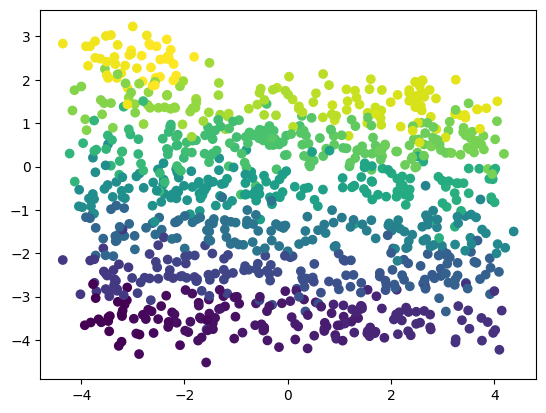

In [10]:
import matplotlib.pyplot as plt

plt.scatter(train_ds.x[:, 0], train_ds.x[:, 1], c=train_ds.y)
